<a href="https://colab.research.google.com/github/hima-prog/AICTE-internship-projects/blob/main/Mall_Customer_Segmentation_using_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mall Customer Segmentation using K-Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [ ]:
data = pd.read_csv("Mall_Customers.csv")
print(data.head())


   CustomerID Customer Names   Genre  Age  Annual Income (k)  Spending Amount 
0           1          Danny    Male   19                 15              1200
1           2           Rony    Male   21                 15              1155
2           3          Daisy  Female   20                 16              6000
3           4        Frankie  Female   23                 16              7000
4           5           Tina  Female   31                 17              9000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         200 non-null    int64 
 1   Customer Names     200 non-null    object
 2   Genre              200 non-null    object
 3   Age                200 non-null    int64 
 4   Annual Income (k)  200 non-null    int64 
 5   Spending Amount    200 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 9.5+ KB
None
       CustomerID         Age  Annual Income (k)  Spending Amount 
count  200.000000  200.000000         200.000000        200.000000
mean   100.500000   38.850000          60.560000      13978.625000
std     57.879185   13.969007          26.264721      21389.731557
min      1.000000   18.000000          15.000000       1000.000000
25%     50.750000   28.750000          41.500000       4000.000000
50%    100.500000   36.000000          61.500000       5500.000

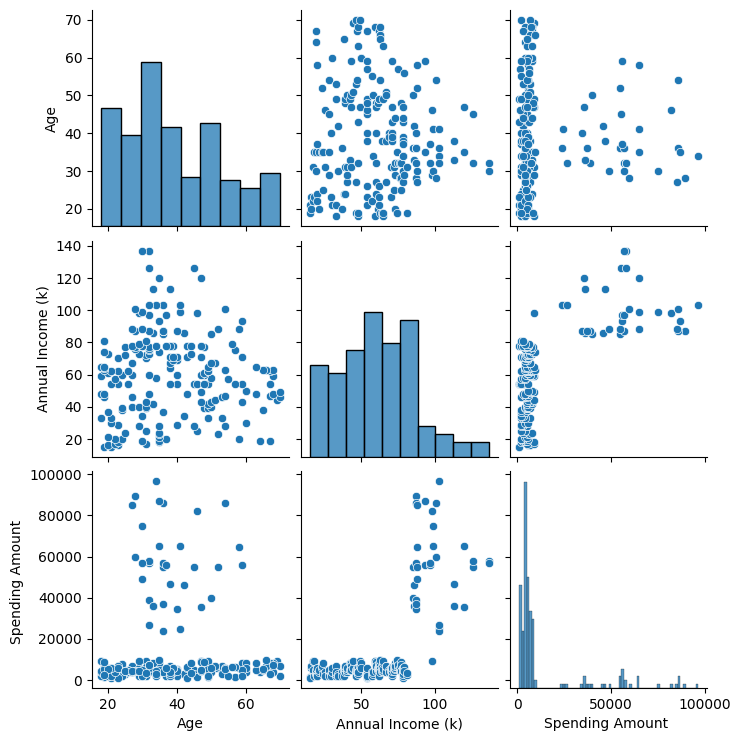

In [ ]:
print(data.info())
print(data.describe())
sns.pairplot(data[['Age', 'Annual Income (k)', 'Spending Amount ']])


In [ ]:
X = data[['Annual Income (k)', 'Spending Amount ']]


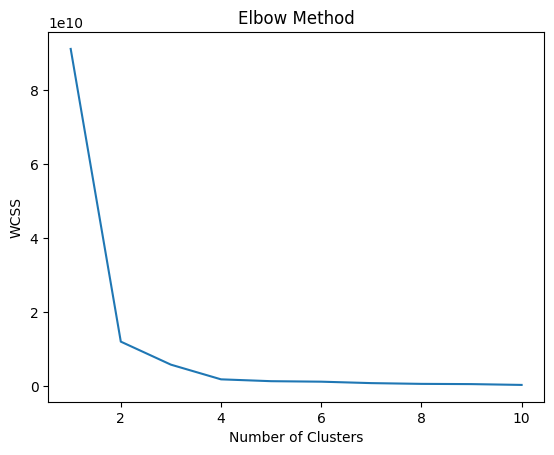

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)


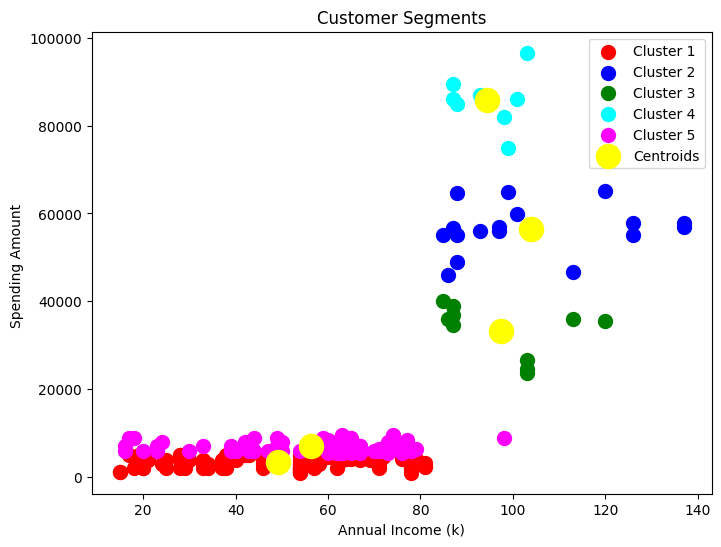

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X.values[y_kmeans == 0, 0], X.values[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X.values[y_kmeans == 1, 0], X.values[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X.values[y_kmeans == 2, 0], X.values[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X.values[y_kmeans == 3, 0], X.values[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X.values[y_kmeans == 4, 0], X.values[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Annual Income (k)')
plt.ylabel('Spending Amount ')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Use features and predicted cluster labels
sil_score = silhouette_score(X, y_kmeans)
calinski_score = calinski_harabasz_score(X, y_kmeans)
davies_score = davies_bouldin_score(X, y_kmeans)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Calinski-Harabasz Index: {calinski_score:.3f}")
print(f"Davies-Bouldin Index: {davies_score:.3f}")


Silhouette Score: 0.598
Calinski-Harabasz Index: 3306.810
Davies-Bouldin Index: 0.439


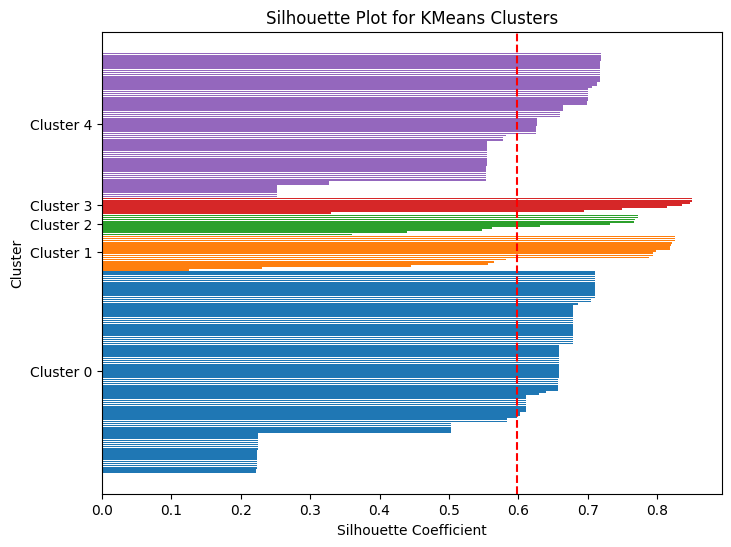

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

silhouette_vals = silhouette_samples(X, y_kmeans)

plt.figure(figsize=(8, 6))
y_ticks = []
y_lower = 0

for i in range(kmeans.n_clusters):
    cluster_silhouette_vals = silhouette_vals[y_kmeans == i]
    cluster_silhouette_vals.sort()
    y_upper = y_lower + cluster_silhouette_vals.shape[0]
    plt.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='none')
    y_ticks.append((y_lower + y_upper) / 2)
    y_lower = y_upper

plt.axvline(sil_score, color='red', linestyle='--')
plt.yticks(y_ticks, [f'Cluster {i}' for i in range(kmeans.n_clusters)])
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.title('Silhouette Plot for KMeans Clusters')
plt.show()


In [ ]:
display(data[['Annual Income (k)', 'Spending Amount ']])

,Annual Income (k),Spending Amount
0,15,1200
1,15,1155
2,16,6000
3,16,7000
4,17,9000
...,...,...
195,120,65125
196,126,55162
197,126,57944
198,137,57900


In [ ]:
# Enter the CustomerID you want to display
customer_ids_to_display = [45, 88, 3, 55] # You can change this to a list of CustomerIDs

customer_data = data[data['CustomerID'].isin(customer_ids_to_display)]

if not customer_data.empty:
    display(customer_data)
else:
    print(f"Customers with CustomerIDs {customer_ids_to_display} not found.")

,CustomerID,Customer Names,Genre,Age,Annual Income (k),Spending Amount
2,3,Daisy,Female,20,16,6000
44,45,Anvitha,Female,49,39,6000
54,55,Rama,Female,50,43,7000
87,88,Sam,Female,22,57,4000
